# SmartFarm ML — Stage 00: Look at the data
**Goal:** no model yet. Just load the sensor CSV and *look* at it — dtypes, ranges, missing values, impossible values.
This is where you catch sensor garbage before it ever reaches a model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


## 1. Load

In [2]:
df = pd.read_csv("irrigation_readings.csv", parse_dates=["timestamp"])
df.shape   # (rows, columns)

(660, 7)

## 2. First look — always .head() before anything

In [3]:
df.head(10)

,timestamp,crop_type,growth_stage,soil_moisture,air_humidity,temperature,irrigated
0,2026-07-01 06:00:00,okra,fruiting,64.7,99.0,21.7,0
1,2026-07-01 06:00:00,tomato,flowering,53.6,99.0,22.7,0
2,2026-07-01 06:00:00,chili,vegetative,52.4,99.0,21.3,1
3,2026-07-01 07:00:00,tomato,fruiting,52.8,95.1,22.6,0
4,2026-07-01 07:00:00,chili,flowering,50.3,93.2,23.9,0
5,2026-07-01 07:00:00,okra,flowering,61.8,94.3,23.7,0
6,2026-07-01 08:00:00,okra,seedling,58.6,88.8,24.6,0
7,2026-07-01 08:00:00,tomato,vegetative,68.2,87.2,25.4,1
8,2026-07-01 08:00:00,chili,fruiting,52.7,83.2,23.8,0
9,2026-07-01 09:00:00,okra,vegetative,58.9,95.4,22.9,0


## 3. Structure — dtypes + non-null counts in one shot

In [4]:
df.info()
# Watch: is timestamp a datetime? are there fewer non-null than total rows? (= missing)

<class 'pandas.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      660 non-null    datetime64[us]
 1   crop_type      660 non-null    str           
 2   growth_stage   660 non-null    str           
 3   soil_moisture  660 non-null    float64       
 4   air_humidity   653 non-null    float64       
 5   temperature    657 non-null    float64       
 6   irrigated      660 non-null    int64         
dtypes: datetime64[us](1), float64(3), int64(1), str(2)
memory usage: 36.2 KB


## 4. describe() — your first garbage detector
Look at **min and max** for each sensor column. A soil_moisture max of 255 or min of -1
is NOT a real reading — it's a capacitive/DHT11 error sentinel leaking into your data.

In [5]:
df.describe()

,timestamp,soil_moisture,air_humidity,temperature,irrigated
count,660,660.000000,653.000000,657.000000,660.000000
mean,2026-07-05 19:30:00,55.809091,84.433538,25.900152,0.086364
min,2026-07-01 06:00:00,-1.000000,48.900000,17.300000,0.000000
25%,2026-07-03 12:45:00,48.400000,74.100000,21.900000,0.000000
50%,2026-07-05 19:30:00,53.900000,86.600000,25.800000,0.000000
75%,2026-07-08 02:15:00,59.600000,97.200000,30.000000,0.000000
max,2026-07-10 09:00:00,255.000000,100.000000,35.200000,1.000000
std,NaN,21.049319,12.708545,4.351165,0.281113


## 5. Categoricals — what crops / stages are actually in here?

In [6]:
print(df["crop_type"].value_counts())
print()
print(df["growth_stage"].value_counts())

crop_type
okra      220
tomato    220
chili     220
Name: count, dtype: int64

growth_stage
seedling      181
fruiting      170
vegetative    157
flowering     152
Name: count, dtype: int64


## 6. Missing values — count them per column

In [7]:
df.isna().sum()

timestamp        0
crop_type        0
growth_stage     0
soil_moisture    0
air_humidity     7
temperature      3
irrigated        0
dtype: int64

## 7. Impossible values — spot them explicitly

In [8]:
# soil moisture is a % → must be 0..100. Anything else is a sensor error.
bad_soil = df[(df["soil_moisture"] < 0) | (df["soil_moisture"] > 100)]
print("rows with impossible soil_moisture:", len(bad_soil))
bad_soil.head()

rows with impossible soil_moisture: 10


,timestamp,crop_type,growth_stage,soil_moisture,air_humidity,temperature,irrigated
65,2026-07-02 03:00:00,chili,flowering,255.0,99.0,21.5,0
146,2026-07-03 06:00:00,chili,seedling,-1.0,99.0,22.3,0
169,2026-07-03 14:00:00,chili,fruiting,-1.0,74.3,31.2,0
177,2026-07-03 17:00:00,okra,vegetative,255.0,74.9,31.2,0
286,2026-07-05 05:00:00,chili,vegetative,-1.0,99.0,19.3,0


## 8. Chart — soil moisture vs air humidity
The Stage 00 build. Notice how the garbage rows (soil = 255) blow out the whole x-axis —
a picture makes bad data obvious in a way a table doesn't.

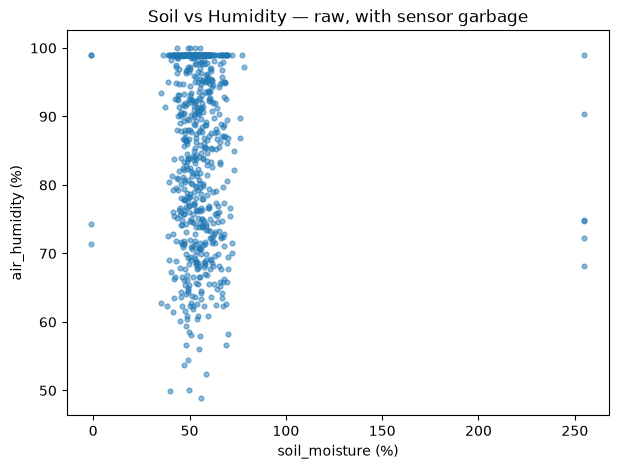

In [9]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(df["soil_moisture"], df["air_humidity"], s=12, alpha=0.5)
ax.set_xlabel("soil_moisture (%)")
ax.set_ylabel("air_humidity (%)")
ax.set_title("Soil vs Humidity — raw, with sensor garbage")
plt.show()

### Same chart, garbage filtered out
Don't clean yet (that's Stage 04) — just *see* the difference filtering makes.

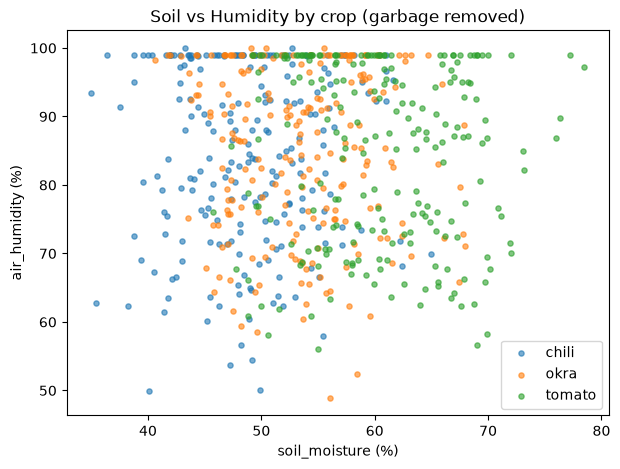

In [10]:
clean = df[(df["soil_moisture"].between(0,100)) & (df["air_humidity"].between(0,100))]
fig, ax = plt.subplots(figsize=(7,5))
for crop, g in clean.groupby("crop_type"):
    ax.scatter(g["soil_moisture"], g["air_humidity"], s=14, alpha=0.6, label=crop)
ax.set_xlabel("soil_moisture (%)"); ax.set_ylabel("air_humidity (%)")
ax.set_title("Soil vs Humidity by crop (garbage removed)")
ax.legend()
plt.show()

## Your turn
1. Which column has the most missing values? Which has impossible ones?
2. Do the three crops sit in different soil-moisture bands? (Eyeball the last chart.)
3. Write 3–4 sentences at the bottom of this notebook describing the data **in your own words** — that's the real Stage 00 deliverable.